# Quantization Aware Training + Knowledge Distillation using Export Model

In [1]:
import os
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import DataLoader
from typing import Callable

from src.utils import load_data, process_callbacks
from src.Quantization.utils.model_setup import qat_kd_setup
from src.utils import compute_loss_and_predictions, calculate_metrics, plot_train_val_curve, test_inference
from src.Quantization.utils.conversions.litert import quantize_pytorch_export_model, convert_pytorch_model_to_tflite, check_quantized_modules
from src.utils import benchmark

2025-04-04 18:16:32.398481: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-04 18:16:32.406450: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1743804992.415515   20940 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743804992.418234   20940 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1743804992.426282   20940 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Specify random seed for repeatable results
_ = torch.manual_seed(191009)

### Helper Functions

In [3]:
def compute_distillation_loss(teacher_logits: torch.Tensor, student_logits: torch.Tensor, T: float) -> torch.Tensor:
    """
    Computes the distillation loss using KL divergence with softened logits.

    Parameters:
        teacher_logits (torch.Tensor): Logits from the teacher model.
        student_logits (torch.Tensor): Logits from the student model.
        T (float): Temperature to soften the logits.

    Returns:
        torch.Tensor: The computed distillation loss.
    """
    soft_loss = F.kl_div(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1),
        reduction='batchmean'
    ) * (T ** 2)
    return soft_loss

### Training QAT + KD

In [4]:
from torchsummary import summary



def train_knowledge_distillation(
    teacher: nn.Module,
    student: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    learning_rate: float,
    epochs: int,
    criterion: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    optimizer: torch.optim.Optimizer,
    callbacks,
    T: float,
    soft_target_loss_weight: float,
    ce_loss_weight: float,
    device: torch.device
) -> None:
    """
    Trains the student model using knowledge distillation from the teacher model.
    The loss is a weighted sum of the KL divergence (distillation loss) and the standard cross entropy loss.
    During validation, the student model is deep-copied and quantized using quantize_pytorch_export_model 
    to ensure the validation is performed on an actually quantized model.
    
    Parameters:
        teacher (nn.Module): The pre-trained teacher model.
        student (nn.Module): The student model to be trained.
        train_loader (DataLoader): DataLoader for the training dataset.
        val_loader (DataLoader): DataLoader for the validation dataset.
        learning_rate (float): Learning rate used for logging
        epochs (int): Number of training epochs.
        criterion (Callable): Loss function for the true label loss (e.g., nn.CrossEntropyLoss).
        optimizer (torch.optim.Optimizer): Optimizer for updating the student model parameters.
        T (float): Temperature for softening the logits.
        soft_target_loss_weight (float): Weight for the distillation (soft targets) loss.
        ce_loss_weight (float): Weight for the cross entropy loss on true labels.
        device (torch.device): Device to perform training on.
    """
    loss_dict = {'train': [], 'val': []}
    # Set teacher to evaluation mode (its parameters won't be updated)
    teacher.eval()
    
    for epoch in range(epochs):
        logs = {"model": student, 
                "batch_size": train_loader.batch_size, 
                "learning_rate": learning_rate, 
                "optimizer": optimizer,
                "criterion": criterion,
                "epoch": epoch}

        # Trigger on_epoch_start callbacks
        for callback in callbacks:
            callback.on_epoch_start(epoch, logs)

        for phase in ['train', 'val']:
            is_train = phase == 'train'

            # For training phase, we use the original student model.
            # For validation, we create a deep copy and quantize it.
            if is_train:
                current_student = student.to(device)
                # Ensure the model is in train mode
                torch.ao.quantization.move_exported_model_to_train(current_student)
            else:
                # Create a deep copy to avoid altering the training model
                current_student = copy.deepcopy(student).to(device)
                # Quantize the copied student model for validation
                # Pass save_dir as None to avoid saving the state dict
                current_student = quantize_pytorch_export_model(current_student, save_dir=None)
                # Switch to evaluation mode to perform inference
                torch.ao.quantization.move_exported_model_to_eval(current_student)

            data_loader = train_loader if is_train else val_loader

            running_loss = 0.0
            total_samples  = 0.0
            predictions, ground_truths, probabilities = [], [], []

            with tqdm(total=len(data_loader), desc=f"{phase.capitalize()} Epoch {epoch + 1}/{epochs}") as pbar:
                for inputs, labels in data_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    
                    # Zero gradients only during training
                    if is_train:
                        optimizer.zero_grad()
                    
                    # Teacher forward pass without gradient computation.
                    with torch.no_grad():
                        teacher = teacher.to(device)
                        teacher_logits = teacher(inputs)
                    
                    # Enable gradients only in training phase
                    with torch.set_grad_enabled(is_train):                        
                        # if(inputs.shape[0] != 32):
                        #     continue

                        # summary(teacher, (3,224,224))
                        # summary(student, (3,224,224))

                        student_logits = current_student(inputs)

                        # Compute soft targets loss using KL divergence.
                        # Using 'batchmean' ensures the loss is averaged over the batch.
                        soft_loss = compute_distillation_loss(teacher_logits=teacher_logits, student_logits=student_logits, T=T)

                        # Compute the true label loss and obtain predictions/probabilities
                        label_loss, probs, preds = compute_loss_and_predictions(student_logits, labels, criterion)
                        
                        # Compute weighted combination of the distillation and cross entropy losses
                        loss = soft_target_loss_weight * soft_loss + ce_loss_weight * label_loss

                        # Backward pass and optimizer step in training phase
                        if is_train:
                            loss.backward()
                            optimizer.step()
                    
                    # Update running loss and sample count
                    batch_size = inputs.size(0)
                    running_loss += loss.item() * batch_size
                    total_samples += batch_size

                    # Accumulate predictions and ground truths for metrics
                    ground_truths.extend(labels.cpu().detach().numpy())
                    predictions.extend(preds.cpu().detach().numpy())
                    probabilities.extend(probs.cpu().detach().numpy())
                    
                    # Update progress bar with average loss so far
                    pbar.set_postfix(loss=f"{running_loss / total_samples:.4f}")
                    pbar.update(1)
                
            # Compute aggregated metrics after epoch
            epoch_loss = running_loss / total_samples
            
            y_true = np.array(ground_truths)
            y_pred = np.array(predictions)
            y_proba = np.array(probabilities) if probabilities else None

            # Calculate metrics
            metrics = calculate_metrics(y_true, y_pred, y_proba)

            loss_dict[phase].append(epoch_loss)
            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f}")
            print(f"{phase.capitalize()} Metrics: " + ", ".join([f"{key}: {value:.4g}" for key, value in metrics.items()]))
            logs.update({f"{phase}_loss": epoch_loss, **metrics})

        # Trigger on_epoch_end callbacks
        for callback in callbacks:
            callback.on_epoch_end(epoch, logs)

        # Check for early stopping
        if any(getattr(cb, "early_stop", False) for cb in callbacks):
            break

    return loss_dict

### Training Loop

In [ ]:
def train_qat_kd(
    teacher_name: str,
    student_name: str,
    data_loaders: dict[str, DataLoader],
    save_dir: str,
    learning_rate: float = 0.001,
    epochs: int = 5,
    criterion: str = "cross_entropy",
    optimizer: str = "adam",
    callbacks: list = None,
    teacher_model_weights: str = None,
    quant_mode: str = "export",
    config: str = "qnnpack",
    class_weights: bool = False,
):
    """
    Trains a student model using Knowledge Distillation (KD) and Quantization-Aware Training (QAT).
    
    This function sets up both the teacher and student models, prepares the student model for 
    QAT, and trains it using knowledge distillation. The function also manages training callbacks, 
    saves checkpoints, and evaluates the final quantized model.

    Parameters:
        teacher_name (str): Name of the pre-trained teacher model (e.g., 'resnet50', 'efficientnet_b0').
        student_name (str): Name of the student model to be trained with QAT.
        data_loaders (dict[str, DataLoader]): Dictionary containing DataLoaders for dataset splits 
                                              (keys: 'train', 'val', optional 'test').
        save_dir (str): Directory where the trained model, checkpoints, and metrics will be saved.
        learning_rate (float, optional): Learning rate for the optimizer. Defaults to 0.001.
        epochs (int, optional): Number of training epochs. Defaults to 5.
        criterion (str, optional): Loss function to use (e.g., 'cross_entropy', 'bce'). Defaults to 'cross_entropy'.
        optimizer (str, optional): Optimizer to use (e.g., 'adam', 'sgd'). Defaults to 'adam'.
        callbacks (list, optional): List of callback functions for monitoring and checkpointing during training. Defaults to None.
        teacher_model_weights (str, optional): Path to pre-trained weights for the teacher model. Defaults to None.
        quant_mode (str, optional): Quantization mode, either 'eager' or 'fx'. Defaults to 'fx'.
        config (str, optional): QAT configuration identifier ('qnnpack' for default qnnpack QAT config or custom). Defaults to 'qnnpack'.
        class_weights (bool, optional): Whether to compute and apply class weights to handle class imbalance. Defaults to False.

    Returns:
        Tuple[nn.Module, nn.Module]: The trained teacher and student models.

    Notes:
        - The student model undergoes quantization-aware training.
        - Knowledge distillation is applied with temperature scaling (T=2) and weighted loss terms.
        - If a test DataLoader is provided, final inference evaluation is performed.
    """
    # Load dataset
    # logging.info("Loading datasets...")
    train_loader = data_loaders["train"]
    val_loader = data_loaders["val"]
    # logging.info("Datasets loaded successfully.")

    # Device configuration - quantization is often done on CPU.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    teacher, student, criterion, optimizer = qat_kd_setup(teacher=teacher_name, 
                                                                student=student_name,
                                                                learning_rate=learning_rate, 
                                                                criterion=criterion, 
                                                                optimizer=optimizer, 
                                                                teacher_model_weights=teacher_model_weights, 
                                                                dataloader=train_loader, 
                                                                quant_mode=quant_mode,
                                                                config=config,
                                                                class_weights=class_weights,
                                                                device=torch.device("cpu"))
    print("FInished setup")
    # Initialize variables for checkpointing
    quantized_model_path = os.path.join(save_dir, f"{student_name}_qat_kd.pth")
    metrics_save_dir = os.path.join(save_dir, "metrics")
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(metrics_save_dir, exist_ok=True)
    # logging.info(f"Training will save checkpoints to: {save_dir}")

    for callback in callbacks:
        callback.on_train_start(logs={})

    # Training loop
    # logging.info("Starting training...")
    # start = time.time()

    # Train the student model using knowledge distillation.
    loss_dict = train_knowledge_distillation(
                            teacher=teacher, 
                            student=student, 
                            train_loader=train_loader,
                            val_loader=val_loader,
                            learning_rate=learning_rate,
                            epochs=epochs, 
                            criterion=criterion,
                            optimizer=optimizer,
                            callbacks=callbacks,
                            T=2, 
                            soft_target_loss_weight=0.25, 
                            ce_loss_weight=0.75, 
                            device=device
                        )
    print("Training completed")
    # time_elapsed = time.time() - start
    # logging.info(f"Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")

    # Trigger training end callbacks
    for callback in callbacks:
        callback.on_train_end(logs={"model": student, "optimizer": optimizer})

    # Load the best model weights before returning
    model_data = torch.load(quantized_model_path, weights_only=True)
    student.load_state_dict(model_data)
    quantized_student = quantize_pytorch_export_model(student, save_dir=os.path.join(save_dir, "quantized_state.pth"))
    # logging.info(f"Best model weights loaded from: {quantized_model_path}")
    plot_train_val_curve(loss_dict, save_path=os.path.join(metrics_save_dir, "loss_curve.png"))

    if data_loaders["test"]:
        test_inference(quantized_student, data_loaders["test"], device, metrics_save_dir)

    return teacher, quantized_student

### Hyperparameters

Model prepared using FX Graph Mode QAT.
FInished setup


Train Epoch 1/1: 100%|██████████| 917/917 [03:02<00:00,  5.02it/s, loss=0.8131]


Train Loss: 0.8131
Train Metrics: Accuracy: 0.7057, Recall: 0.5231, Precision: 0.6465, F1-Score: 0.5441, AUC-Score: 0.9458
Quantized PyTorch model.


Val Epoch 1/1: 100%|██████████| 115/115 [00:20<00:00,  5.52it/s, loss=0.7558]
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Val Loss: 0.7558
Val Metrics: Accuracy: 0.7339, Recall: 0.6032, Precision: 0.6102, F1-Score: 0.5801, AUC-Score: 0.9618
Training completed
Quantized PyTorch model.


Inference Progress: 100%|██████████| 115/115 [00:20<00:00,  5.65it/s]
/home/jacob-delgado/anaconda3/envs/ECG/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Metrics Results:
Accuracy: 0.7311
Recall: 0.5947
Precision: 0.6268
F1-Score: 0.5757
AUC-Score: 0.9612


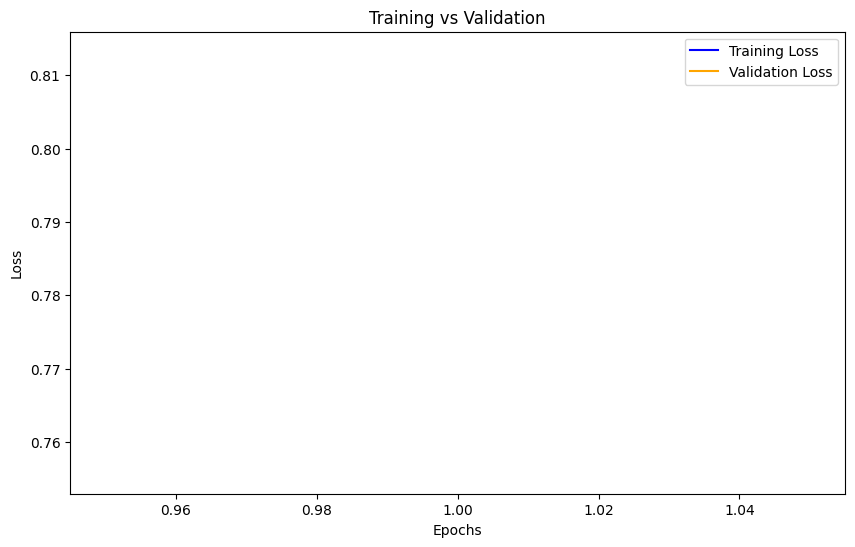

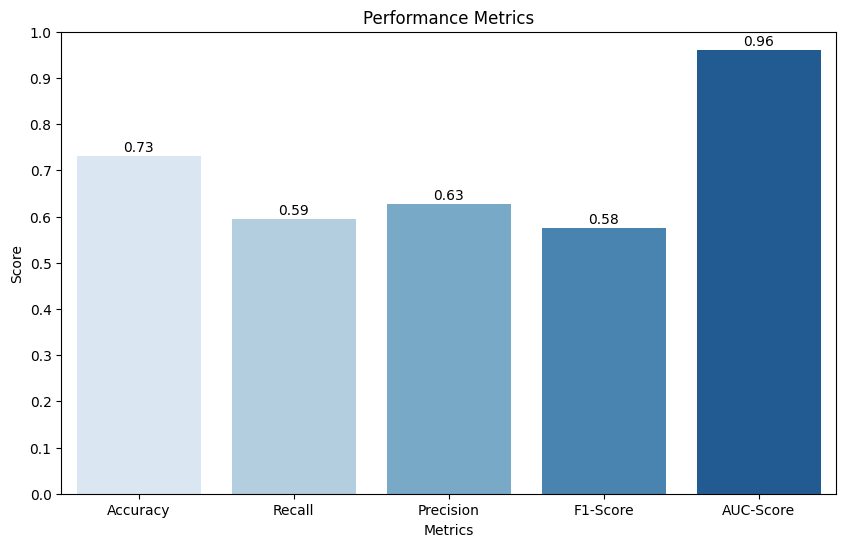

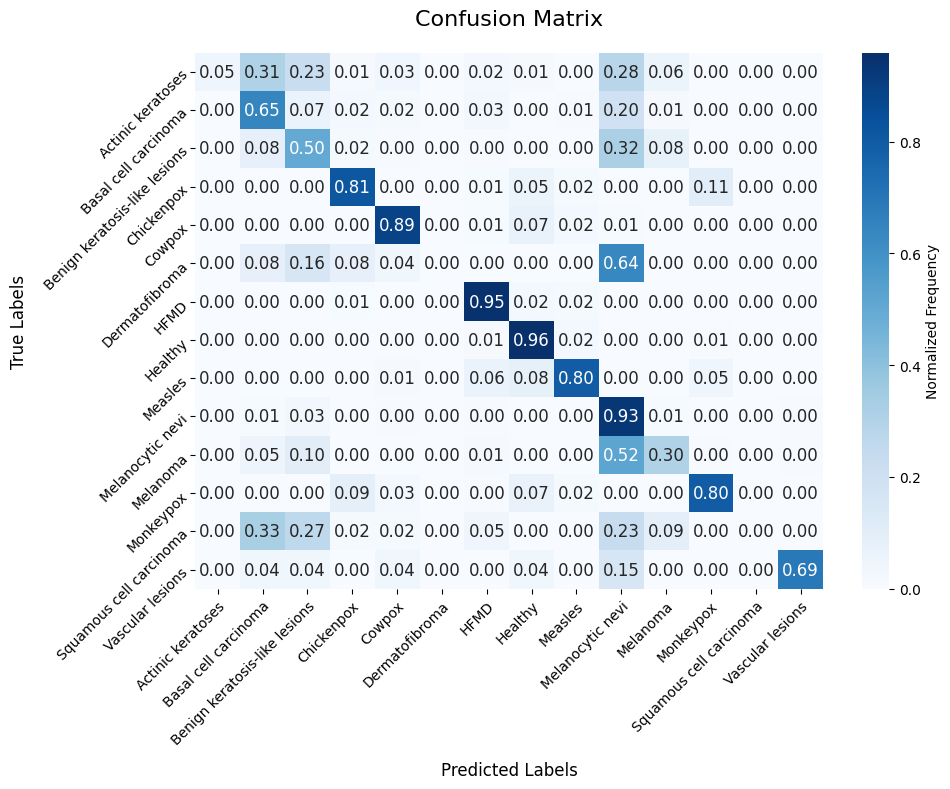

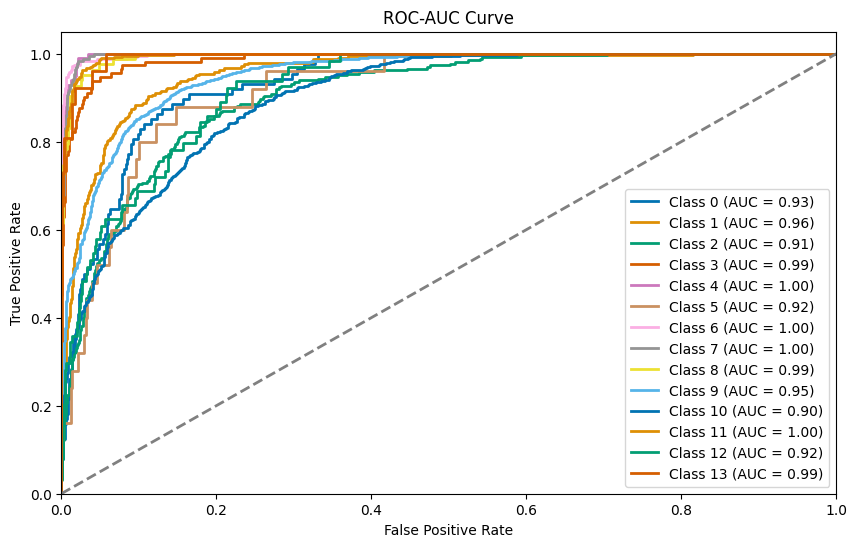

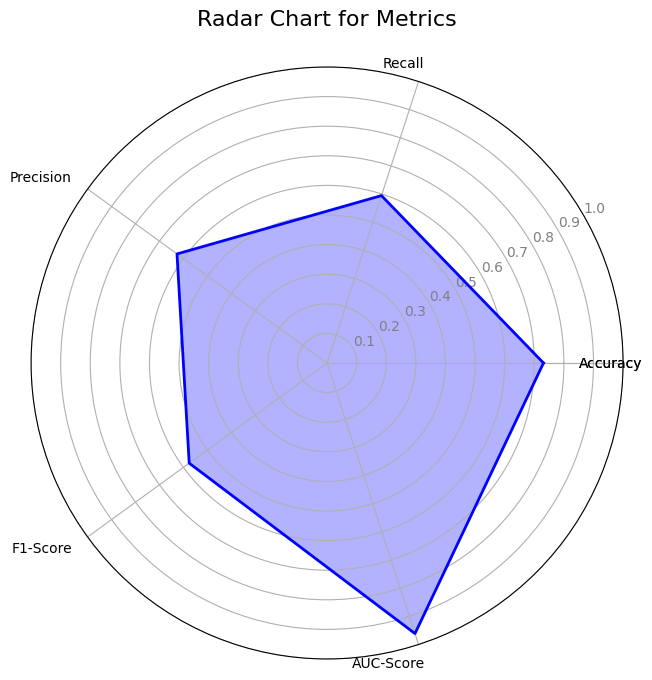

In [6]:
dataset = "SkinCancer"
batch_size = 32
learning_rate = 0.001
epochs = 1
save_dir = f"models/{dataset}/Quantized"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
teacher_model = "mobilenet_v2"
student_model = "mobilenet_v2"
args = {"callbacks": ["ModelCheckpoint", "EarlyStopping", "ReduceLROnPlateau"], 
        "save_dir": save_dir, 
        "model_name": student_model,
        "save_name": "qat_kd"}
CALLBACKS = list(process_callbacks(args).values())

os.makedirs(save_dir, exist_ok=True)

dataloaders = load_data(dataset=dataset, batch_size=batch_size)

teacher_model_weights = 'models/SkinCancer/mobilenet_v2_best_model.pth'  # Update with your saved model weights

criterion = "cross_entropy"
optimizer = "adam"

teacher, quantized_student = train_qat_kd(
                                        teacher_name=teacher_model, 
                                        student_name=student_model,
                                        data_loaders=dataloaders,
                                        save_dir=save_dir,
                                        learning_rate=learning_rate,
                                        epochs=epochs,
                                        criterion = criterion,
                                        optimizer = optimizer,
                                        callbacks=CALLBACKS,
                                        teacher_model_weights=teacher_model_weights
                                )


In [7]:
benchmark(model1=teacher.to("cpu"), model2=quantized_student.to("cpu"), dataloader=dataloaders["test"], device=torch.device("cpu"))

Label : inference
Begin : Fri Apr  4 18:21:50 2025
Duration : 5000071.5210 us
-------------------------------
PKG :
	socket 0 :  434217840.0000 uJ
Label : inference
Begin : Fri Apr  4 18:21:58 2025
Duration : 4437564.1210 us
-------------------------------
PKG :
	socket 0 :  523645573.0000 uJ
Label : inference
Begin : Fri Apr  4 18:22:04 2025
Duration : 11160205.6480 us
-------------------------------
PKG :
	socket 0 :  1357361186.0000 uJ
                             Metric  Model 1  Model 2
                    Model Size (MB)   9.1899   8.9829
        Inference Time (sec/sample) 0.002999 0.011765
           Throughput (samples/sec)   333.40    85.00
                  Memory Usage (MB)  2194.89  2194.49
                 Idle Power (Watts)    86.84        -
                  Avg Power (Watts)   118.00   121.62
         Energy per Sample (Joules) 0.353921 1.430894
Throughput per Watt (samples/sec/W)     2.83     0.70
                  Latency P50 (sec) 0.220787 0.863880
                 

### Final Quantization for model (Turn Fake-Quant tensors into real quant tensors)

In [ ]:
quant_copy = copy.deepcopy(quantized_student).to("cpu")

In [ ]:
quant_copy.print_readable()

In [ ]:
check_quantized_modules(quant_copy)

In [ ]:
example_inputs = next(iter(dataloaders["train"]))[0].to("cpu")
convert_pytorch_model_to_tflite(quant_copy, os.path.join(save_dir, f"{student_model}.tflite"), (example_inputs,))

In [ ]:
print("qat_kd: ", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2_qat_kd.pth") / 1e6)
print("quantized_state: ", os.path.getsize("models/SkinCancer/Quantized/quantized_state.pth") / 1e6)
print("TFlite:", os.path.getsize("models/SkinCancer/Quantized/mobilenet_v2.tflite") / 1e6)

In [ ]:
print(quantized_student)

In [ ]:
quantized_student.print_readable()

In [ ]:
print(quantized_student.graph)